# Sim2Real asset-backed simulation workflow

Sim2Real is different from the CoAX and CoXAM workflows: the AI predictions, LIME attributions, counterfactual rows, and ground-truth direction labels are a fixed corpus under `assets/`. This notebook therefore skips `train_AI_model(...)` and `study.explanations(...)`.

The workflow here is:

1. Load the Sim2Real asset corpus and precomputed explanations.
2. Inspect one explanation through the same `xai_adapter` path used elsewhere.
3. Build trial rows constrained to the Sim2Real corpus.
4. Run the Sim2Real cognitive model from those trials.
5. Save, analyze, and plot the simulated results.

In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "assets").is_dir():
            return candidate
    raise RuntimeError("Could not find the repository root. Open this notebook from inside xaikit-test-api.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("Repository root:", REPO_ROOT)

from src.api import xaikitTest
from src.data_loaders import UnifiedDataLoader
from src.xai_adapter import create_xai_method
from src.virtual_experiment_executor.experiment_simualtion.Sim2Real.sim2real_trial_executor import (
    BASELINE_EXP_PROPERTY,
    FITTED_SIM2REAL_PARAMS,
    SIM2REAL_EXP_PROPERTIES,
    build_sim2real_projector,
    fitted_sim2real_params,
    sim2real_available_instance_ids,
)
from src.virtual_experiment_executor.experiment_simualtion.Sim2Real.sim2real_study_runner import (
    run_sim2real_study,
)

ASSETS_ROOT = REPO_ROOT / "assets"
OUTPUT_DIR = REPO_ROOT / "tutorials" / "sim2real_asset_workflow_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)

Repository root: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api


## 1. Load the fixed Sim2Real corpus

`UnifiedDataLoader.from_assets("sim2real", ...)` reads `assets/ai_dataset/sim2real` plus `assets/explanations/xai_desiderata`. No source CSV is modified.

In [2]:
loader = UnifiedDataLoader.from_assets(
    "sim2real",
    assets_root=ASSETS_ROOT,
    app_id="adult_sim2real",
    model_name="synthetic_ai",
)

loader.get_summary(), loader.list_explanation_tables()

({'source_type': 'sim2real',
  'n_instances': 39,
  'n_features': 67,
  'n_apps': 1,
  'app_ids': ['adult_sim2real'],
  'has_predictions': True,
  'n_explanation_columns': 0,
  'filters_applied': 0},
 ['attribution', 'counterfactuals_fake', 'deltas', 'importance', 'none'])

In [3]:
attribution_assets = loader.get_explanation_table("attribution")
counterfactual_assets = loader.get_explanation_table("counterfactuals_fake")
delta_assets = loader.get_explanation_table("deltas")

display(attribution_assets.head())
display(delta_assets.head())

,appId,modelName,expMethod,expProperty,instanceId,qid,pred,i_max,a0_i,a1_i,...,a58_i,a59_i,a60_i,a61_i,a62_i,a63_i,a64_i,a65_i,a66_i,intercept
0,adult_sim2real,synthetic_ai,lime,faithful,0,12,0,8.08,0.09,0.40,...,0.01,0.01,-0.01,0.02,0.01,0.01,0.00,-0.02,0.00,NaN
1,adult_sim2real,synthetic_ai,lime,robust,0,12,0,2.72,0.20,2.33,...,0.11,0.05,-0.03,0.06,0.09,0.04,0.05,-0.13,0.05,NaN
2,adult_sim2real,synthetic_ai,lime,sparse,0,12,0,7.58,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
3,adult_sim2real,synthetic_ai,lime,sparse_robust,0,12,0,2.42,0.11,2.38,...,0.02,0.00,0.00,0.00,0.00,0.00,0.00,-0.04,0.00,NaN
4,adult_sim2real,synthetic_ai,lime,NaN,0,12,0,4.36,-0.01,1.05,...,0.08,0.37,0.28,-0.07,0.18,0.10,-0.05,-0.11,0.04,NaN


,appId,instanceId,split,presentationOrder,sourceCase,qid,questionType,feature,featureKind,valueFrom,...,sourceDimFrom,valueFromMatchesInstance,sourceValueFromMatchesInstance,counterfactualHasChange,deltaDirectionReversed,changedDimensions,mappingStatus,rawDelta,originalPrediction,answer
0,adult_sim2real,0,training,6,case_0,12,NaN,relationship,categorical,Not-in-family,...,51,1,1,1,0,51;55,matched,relationship: Not-in-family <span style='color...,0,1
1,adult_sim2real,1,training,7,case_1,14,NaN,sex,categorical,Female,...,56,1,1,1,0,56;57,matched,sex: Female <span style='color:red;'>→ Male</s...,0,1
2,adult_sim2real,2,training,8,case_2,16,NaN,capital-gain,numeric,0.0,...,1,1,1,1,0,1,matched,capital-gain: 0 <span style='color:red;'>→ 120...,0,1
3,adult_sim2real,3,training,9,case_3,17,NaN,marital,categorical,Married-civ-spouse,...,22,1,1,1,0,21;22,matched,marital: Married-civ-spouse <span style='color...,0,1
4,adult_sim2real,4,training,10,case_4,18,NaN,education,categorical,HS-grad,...,15,1,1,1,0,13;15,matched,education: HS-grad <span style='color:red;'>→ ...,0,1


## 2. Inspect precomputed explanations through `xai_adapter`

The Sim2Real study varies `xai_property` (`faithful`, `sparse`, `robust`, `sparse_robust`), not the explanation method. The method is the precomputed LIME attribution table.

In [4]:
faithful_lime = create_xai_method(
    "csv",
    loader=loader,
    explanation_type="attribution",
    exp_property="faithful",
    model_name="synthetic_ai",
)

baseline_lime = create_xai_method(
    "csv",
    loader=loader,
    explanation_type="attribution",
    model_name="synthetic_ai",
)

instance_ids = [0, 1, 2]
faithful_result = faithful_lime.explain(instance_ids)
baseline_result = baseline_lime.explain(instance_ids)

print("faithful attribution matrix:", faithful_result.values.shape)
print("baseline attribution matrix:", baseline_result.values.shape)
display(faithful_lime.get_records([0])[0].metadata)

faithful attribution matrix: (3, 67)
baseline attribution matrix: (3, 67)


{'appId': 'adult_sim2real',
 'modelName': 'synthetic_ai',
 'expMethod': 'lime',
 'expProperty': 'faithful',
 'qid': 12,
 'i_max': 8.08}

## 3. Build the projector used by the executor

`build_sim2real_projector()` is the bridge from the 67-dimensional asset tables to the 12 raw Adult features that the cognitive model reads. It also owns the counterfactual answer label from `deltas.csv`.

In [5]:
projector = build_sim2real_projector()
available_ids = sim2real_available_instance_ids(projector)
testing_ids = sim2real_available_instance_ids(projector, split="test")
training_ids = sim2real_available_instance_ids(projector, split="training")

print(f"available instances: {len(available_ids)}")
print(f"training split: {len(training_ids)}")
print(f"test split: {len(testing_ids)}")
print("properties:", SIM2REAL_EXP_PROPERTIES)

pair = projector.project(testing_ids[0], exp_property="faithful")
display(pair.to_frame())

available instances: 39
training split: 10
test split: 29
properties: ('faithful', 'sparse', 'robust', 'sparse_robust')


,feature,original_dimension,changed_dimension,original_dimension_name,changed_dimension_name,original_value,changed_value,original_attribution,changed_attribution,is_changed
0,age,0,0,age,age,41.0,41.0,0.81,0.81,False
1,capital-gain,1,1,capital-gain,capital-gain,0.0,0.0,6.69,6.69,False
2,capital-loss,2,2,capital-loss,capital-loss,0.0,0.0,0.69,0.69,False
3,education,13,17,education_Bachelors,education_Preschool,Bachelors,Preschool,0.46,-0.47,True
4,hours-per-week,3,3,hours-per-week,hours-per-week,40.0,40.0,0.90,0.90,False
5,marital,24,24,marital_Never-married,marital_Never-married,Never-married,Never-married,-0.52,-0.52,False
6,native-country,27,27,native-country_United-States,native-country_United-States,United-States,United-States,0.68,0.68,False
7,occupation,39,39,occupation_Prof-specialty,occupation_Prof-specialty,Prof-specialty,Prof-specialty,0.29,0.29,False
8,race,49,49,race_White,race_White,White,White,0.10,0.10,False
9,relationship,51,51,relationship_Not-in-family,relationship_Not-in-family,Not-in-family,Not-in-family,0.20,0.20,False


## 4. Build trial rows from the fixed corpus

The executor expects trial rows with `participantId`, `instanceId`, `phase`, and an explanation-condition column such as `xai_property`. The key guardrail is that every `instanceId` must exist in the Sim2Real corpus.

In [6]:
def make_sim2real_trials(
    *,
    participant_ids=range(1, 9),
    properties=SIM2REAL_EXP_PROPERTIES,
    candidate_instance_ids=testing_ids,
    trials_per_property=8,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    candidate_instance_ids = list(candidate_instance_ids)
    rows = []

    for participant_id in participant_ids:
        for prop in properties:
            sampled = rng.choice(
                candidate_instance_ids,
                size=min(trials_per_property, len(candidate_instance_ids)),
                replace=False,
            )
            for order, instance_id in enumerate(sampled, start=1):
                rows.append(
                    {
                        "participantId": int(participant_id),
                        "trialIndex": int(order),
                        "phase": "testing",
                        "instanceId": int(instance_id),
                        "xai_type": "attribution",
                        "xai_property": prop,
                        "modelName": "synthetic_ai",
                    }
                )
    return pd.DataFrame(rows)


trials = make_sim2real_trials()
assert set(trials["instanceId"]) <= set(available_ids)

display(trials.head())
display(trials.groupby(["xai_property", "phase"]).size().reset_index(name="n_trials"))

,participantId,trialIndex,phase,instanceId,xai_type,xai_property,modelName
0,1,1,testing,12,attribution,faithful,synthetic_ai
1,1,2,testing,30,attribution,faithful,synthetic_ai
2,1,3,testing,33,attribution,faithful,synthetic_ai
3,1,4,testing,25,attribution,faithful,synthetic_ai
4,1,5,testing,21,attribution,faithful,synthetic_ai


,xai_property,phase,n_trials
0,faithful,testing,64
1,robust,testing,64
2,sparse,testing,64
3,sparse_robust,testing,64


## 5. Create the study shell

This shell gives the runner a design and DV dictionary. We do not call `prepare_dataset`, `train_AI_model`, or `explanations`, because Sim2Real reads the fixed assets through the projector.

In [7]:
study = xaikitTest("sim2real_asset_workflow", output_dir=OUTPUT_DIR)
study.add_iv("xai_property", "within", list(SIM2REAL_EXP_PROPERTIES), randomization="block")
study.add_dv("counterfactual_accuracy", [0, 1])
study.set_cognitive_model(cognitive_model_id="sim2real")

study.trials = trials.to_dict("records")
study.validate_design(show=True)

print("cognitive model:", study.cognitive_model_id)
print("stored trials:", len(study.trials))


IV configuration:
  xai_property         type=within   randomization=block levels=['faithful', 'sparse', 'robust', 'sparse_robust']

CVs: []
DVs: ['counterfactual_accuracy']
cognitive model: sim2real
stored trials: 256


## 6. Run the Sim2Real simulation

`strategy="attribution_sum"` uses the fitted attribution-sum model. You can also run `sensitive_features` or `salient_features`; those exemplar strategies are fitted on the projector's Sim2Real training split before they simulate.

In [8]:
results = run_sim2real_study(
    study,
    mode="whole_experiment",
    strategy="attribution_sum",
    normalize_by_i_max=True,
    store=True,
)

display(results.head())
display(
    results.groupby("xai_property")["counterfactual_accuracy"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)

,counterfactual_accuracy,participantId,trialIndex,phase,instanceId,xai_type,xai_property,modelName,exp_property,qid,...,probability_income_increases,agent_response_increases,ground_truth_increases,counterfactual_correct,changed_feature_visible,changed_feature_names,retrieved_exemplar_count,effective_lapse_rate,response_lapse_rate,response_lapsed
0,1,1,1,testing,12,attribution,faithful,synthetic_ai,faithful,2,...,0.474094,0,0,1,True,education,0,0.0,0.0,False
1,1,1,2,testing,30,attribution,faithful,synthetic_ai,faithful,20,...,0.548547,1,1,1,False,marital,0,0.0,0.0,False
2,1,1,3,testing,33,attribution,faithful,synthetic_ai,faithful,23,...,0.548547,1,1,1,True,age,0,0.0,0.0,False
3,1,1,4,testing,25,attribution,faithful,synthetic_ai,faithful,15,...,0.548547,1,1,1,True,hours-per-week,0,0.0,0.0,False
4,1,1,5,testing,21,attribution,faithful,synthetic_ai,faithful,11,...,0.548547,1,1,1,True,hours-per-week,0,0.0,0.0,False


,xai_property,mean,sem,count
0,faithful,0.906250,0.036723,64
1,robust,0.890625,0.039322,64
2,sparse,0.359375,0.060451,64
3,sparse_robust,0.609375,0.061468,64


## 7. Run a subset for UI step-through behavior

The runner accepts the same `mode` vocabulary as the server API: `trial_by_trial`, `participant_by_participant`, `whole_condition`, and `whole_experiment`.

In [9]:
participant_preview = run_sim2real_study(
    study,
    mode="participant_by_participant",
    participant_id=1,
    strategy="attribution_sum",
    store=False,
)

robust_preview = run_sim2real_study(
    study,
    mode="whole_condition",
    condition_filter={"xai_property": "robust"},
    strategy="attribution_sum",
    store=False,
)

print("participant 1 rows:", len(participant_preview))
print("robust condition rows:", len(robust_preview))
display(participant_preview.head())

participant 1 rows: 32
robust condition rows: 64


,counterfactual_accuracy,participantId,trialIndex,phase,instanceId,xai_type,xai_property,modelName,exp_property,qid,...,probability_income_increases,agent_response_increases,ground_truth_increases,counterfactual_correct,changed_feature_visible,changed_feature_names,retrieved_exemplar_count,effective_lapse_rate,response_lapse_rate,response_lapsed
0,0,1,1,testing,12,attribution,faithful,synthetic_ai,faithful,2,...,0.548547,1,0,0,True,education,0,0.0,0.0,False
1,1,1,2,testing,30,attribution,faithful,synthetic_ai,faithful,20,...,0.548547,1,1,1,False,marital,0,0.0,0.0,False
2,1,1,3,testing,33,attribution,faithful,synthetic_ai,faithful,23,...,0.548547,1,1,1,True,age,0,0.0,0.0,False
3,1,1,4,testing,25,attribution,faithful,synthetic_ai,faithful,15,...,0.548547,1,1,1,True,hours-per-week,0,0.0,0.0,False
4,1,1,5,testing,21,attribution,faithful,synthetic_ai,faithful,11,...,0.548547,1,1,1,True,hours-per-week,0,0.0,0.0,False


## 8. Compare cognitive strategies

This cell is useful when deciding which strategy your UI should expose as the default. The current server request field is `sim2real_strategy`.

In [10]:
strategy_frames = []
for strategy in ["attribution_sum", "sensitive_features", "salient_features"]:
    frame = run_sim2real_study(
        study,
        mode="whole_experiment",
        strategy=strategy,
        normalize_by_i_max=True,
        store=False,
    ).copy()
    frame["strategy"] = strategy
    strategy_frames.append(frame)

strategy_results = pd.concat(strategy_frames, ignore_index=True)
strategy_summary = (
    strategy_results.groupby(["strategy", "xai_property"])["counterfactual_accuracy"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)

display(strategy_summary)

,strategy,xai_property,mean,sem,count
0,attribution_sum,faithful,0.906250,0.036723,64
1,attribution_sum,robust,0.890625,0.039322,64
2,attribution_sum,sparse,0.359375,0.060451,64
3,attribution_sum,sparse_robust,0.609375,0.061468,64
4,salient_features,faithful,0.296875,0.057562,64
5,salient_features,robust,0.328125,0.059155,64
6,salient_features,sparse,0.375000,0.060994,64
7,salient_features,sparse_robust,0.281250,0.056645,64
8,sensitive_features,faithful,0.953125,0.026630,64
9,sensitive_features,robust,0.843750,0.045745,64


## 9. Save and analyze results

Because `store=True` was used for the attribution-sum run, the standard `xaikitTest` result helpers can now read `study.simulated_results`.

In [11]:
csv_path, json_path = study.save_results(out_dir="simulated_results")
print(csv_path)
print(json_path)

analysis = study.analyze_iv_dv(iv="xai_property", dv="counterfactual_accuracy")
analysis

/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_asset_workflow_output/simulated_results/simulated_results.csv
/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_asset_workflow_output/simulated_results/simulated_results.json


/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


IVDVAnalysisResult(iv='xai_property', dv='counterfactual_accuracy', method='mixed_effects', descriptives=   index   xai_property  count      mean       std       sem
0      0       faithful      8  0.906250  0.057864  0.020458
1      1         robust      8  0.890625  0.104315  0.036881
2      2         sparse      8  0.359375  0.104315  0.036881
3      3  sparse_robust      8  0.609375  0.169525  0.059936, inferential=MixedEffectsResult(model=<statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper object at 0x15b6c74f0>, formula="Q('counterfactual_accuracy') ~ C(Q('xai_property'))", groups='participantId', summary="                     Mixed Linear Model Regression Results\n================================================================================\nModel:              MixedLM   Dependent Variable:   Q('counterfactual_accuracy')\nNo. Observations:   32        Method:               REML                        \nNo. Groups:         8         Scale:                0.0134   

ResultGrid(figure=<Figure size 340x280 with 1 Axes>, axes=array([[<Axes: title={'center': 'Counterfactual Accuracy by XAI Property'}, xlabel='XAI Property', ylabel='Counterfactual Accuracy'>]],
      dtype=object), summary=             iv                       dv  index          level  count  \
0  xai_property  counterfactual_accuracy      0       faithful      8   
1  xai_property  counterfactual_accuracy      1         robust      8   
2  xai_property  counterfactual_accuracy      2         sparse      8   
3  xai_property  counterfactual_accuracy      3  sparse_robust      8   

       mean       std       sem      ci95  
0  0.906250  0.057864  0.020458  0.048375  
1  0.890625  0.104315  0.036881  0.087210  
2  0.359375  0.104315  0.036881  0.087210  
3  0.609375  0.169525  0.059936  0.141727  )

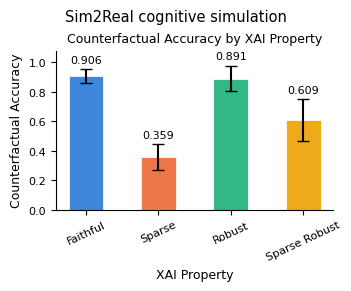

In [12]:
fig = study.plot_results_grid(
    ivs=["xai_property"],
    dvs=["counterfactual_accuracy"],
    title="Sim2Real cognitive simulation",
)
fig

## 10. Human data fitting plots

The anonymized fitted-human tables live under `assets/human_data/Sim2Real/`. The raw fitting runs under `server_runs/` also include PNG diagnostics; this section shows both when they are available.

In [13]:
from IPython.display import HTML, Image, display
from src.result_visualizer import human_vs_model_report, load_sim2real_fitted_trials, study_comparison

fit_table_path = ASSETS_ROOT / "human_data" / "Sim2Real" / "sim2real_participant_fits.csv"
prediction_table_path = ASSETS_ROOT / "human_data" / "Sim2Real" / "sim2real_fit_predictions.csv"

participant_fits = pd.read_csv(fit_table_path)
fit_predictions = load_sim2real_fitted_trials()

print("participant fits:", participant_fits.shape)
print("fit predictions:", None if fit_predictions is None else fit_predictions.shape)

display(
    participant_fits.groupby(["exp_property", "strategy"])
    .agg(
        participants=("participant_id", "nunique"),
        mean_match=("test_accuracy_model_participant", "mean"),
        mean_human_accuracy=("test_accuracy_participant_answer_key", "mean"),
        mean_bic=("test_bic_model_participant", "mean"),
    )
    .reset_index()
)

display(participant_fits.head())

participant fits: (46, 32)
fit predictions: (1334, 23)


,exp_property,strategy,participants,mean_match,mean_human_accuracy,mean_bic
0,faithful,attribution_sum,11,0.702194,0.670846,65.228873
1,faithful,sensitive_features,1,0.758621,0.827586,48.470479
2,robust,attribution_sum,11,0.896552,0.924765,45.692741
3,sparse,attribution_sum,3,0.632184,0.505747,73.936561
4,sparse,salient_features,3,0.655172,0.804598,53.079281
5,sparse,sensitive_features,6,0.770115,0.833333,47.419605
6,sparse_robust,attribution_sum,3,0.735632,0.873563,58.129608
7,sparse_robust,salient_features,1,0.758621,0.896552,39.705764
8,sparse_robust,sensitive_features,7,0.881773,0.950739,37.474042


,participant_id,explanation_type,exp_property,n_trials,n_training_feedback_cases,training_instance_ids,aggregation,normalize_by_i_max,confidence_scale,confidence_intercept,...,comparison_scale,comparison_intercept,training_feedback_accuracy,test_nll_model_participant,test_total_nll_model_participant,n_parameters,test_bic_model_participant,test_accuracy_model_participant,test_brier_model_participant,test_accuracy_participant_answer_key
0,41,0,faithful,29,10,0;1;2;3;4;5;6;7;8;9,attribution,True,2.0,1.0,...,896.582825,0.334868,0.8,0.447244,12.970088,10,59.613135,0.793103,0.151397,0.758621
1,40,0,faithful,29,10,0;1;2;3;4;5;6;7;8;9,attribution,True,2.0,-1.0,...,106.275436,0.167031,0.8,0.562652,16.316912,11,69.674079,0.724138,0.193837,0.793103
2,28,0,faithful,29,10,0;1;2;3;4;5;6;7;8;9,value_weighted,False,128.0,0.0,...,56.143138,-0.135053,0.6,0.507079,14.705283,11,66.450820,0.586207,0.183584,0.827586
3,29,0,faithful,29,10,0;1;2;3;4;5;6;7;8;9,attribution,False,0.5,0.0,...,620.561839,0.158174,0.8,0.425699,12.345272,10,58.363502,0.862069,0.143176,0.827586
4,25,0,faithful,29,10,0;1;2;3;4;5;6;7;8;9,attribution,True,8.0,-1.0,...,101.173093,-0.288684,0.8,0.644410,18.687899,11,74.416052,0.517241,0.229757,0.517241


In [14]:
sim2real_comparison = study_comparison("sim2real")
if sim2real_comparison is None:
    raise FileNotFoundError("No consolidated Sim2Real human-fit table found under assets/human_data/Sim2Real.")

for panel in sim2real_comparison.panels:
    print(panel.title)
    display(panel.to_frame())

report_path = human_vs_model_report(
    "sim2real",
    output_path=OUTPUT_DIR / "human_vs_sim2real.html",
    title="Human vs Sim2Real fitted model",
)
display(HTML(f'<a href="{report_path}" target="_blank">Open human-vs-Sim2Real report</a>'))
print(report_path)

Accuracy, by explanation property


,series,category,mean,error,interval,n
0,Human,Faithful,0.683908,0.119212,95% CI,12
1,Human,Sparse,0.744253,0.098185,95% CI,12
2,Human,Robust,0.924765,0.072386,95% CI,11
3,Human,Sparse + robust,0.924765,0.028968,95% CI,11
4,sim2real,Faithful,0.770115,0.152175,95% CI,12
5,sim2real,Sparse,0.744253,0.104222,95% CI,12
6,sim2real,Robust,0.934169,0.078528,95% CI,11
7,sim2real,Sparse + robust,0.849530,0.077023,95% CI,11


How often the model reproduces the human responses


,series,category,mean,error,interval,n
0,sim2real,Faithful,0.706897,0.075608,95% CI,12
1,sim2real,Sparse,0.706897,0.070840,95% CI,12
2,sim2real,Robust,0.896552,0.091498,95% CI,11
3,sim2real,Sparse + robust,0.830721,0.050174,95% CI,11


/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_asset_workflow_output/human_vs_sim2real.html


/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/server_runs/sim2real_attribution_sum/human_vs_coax_ans_accuracy.png


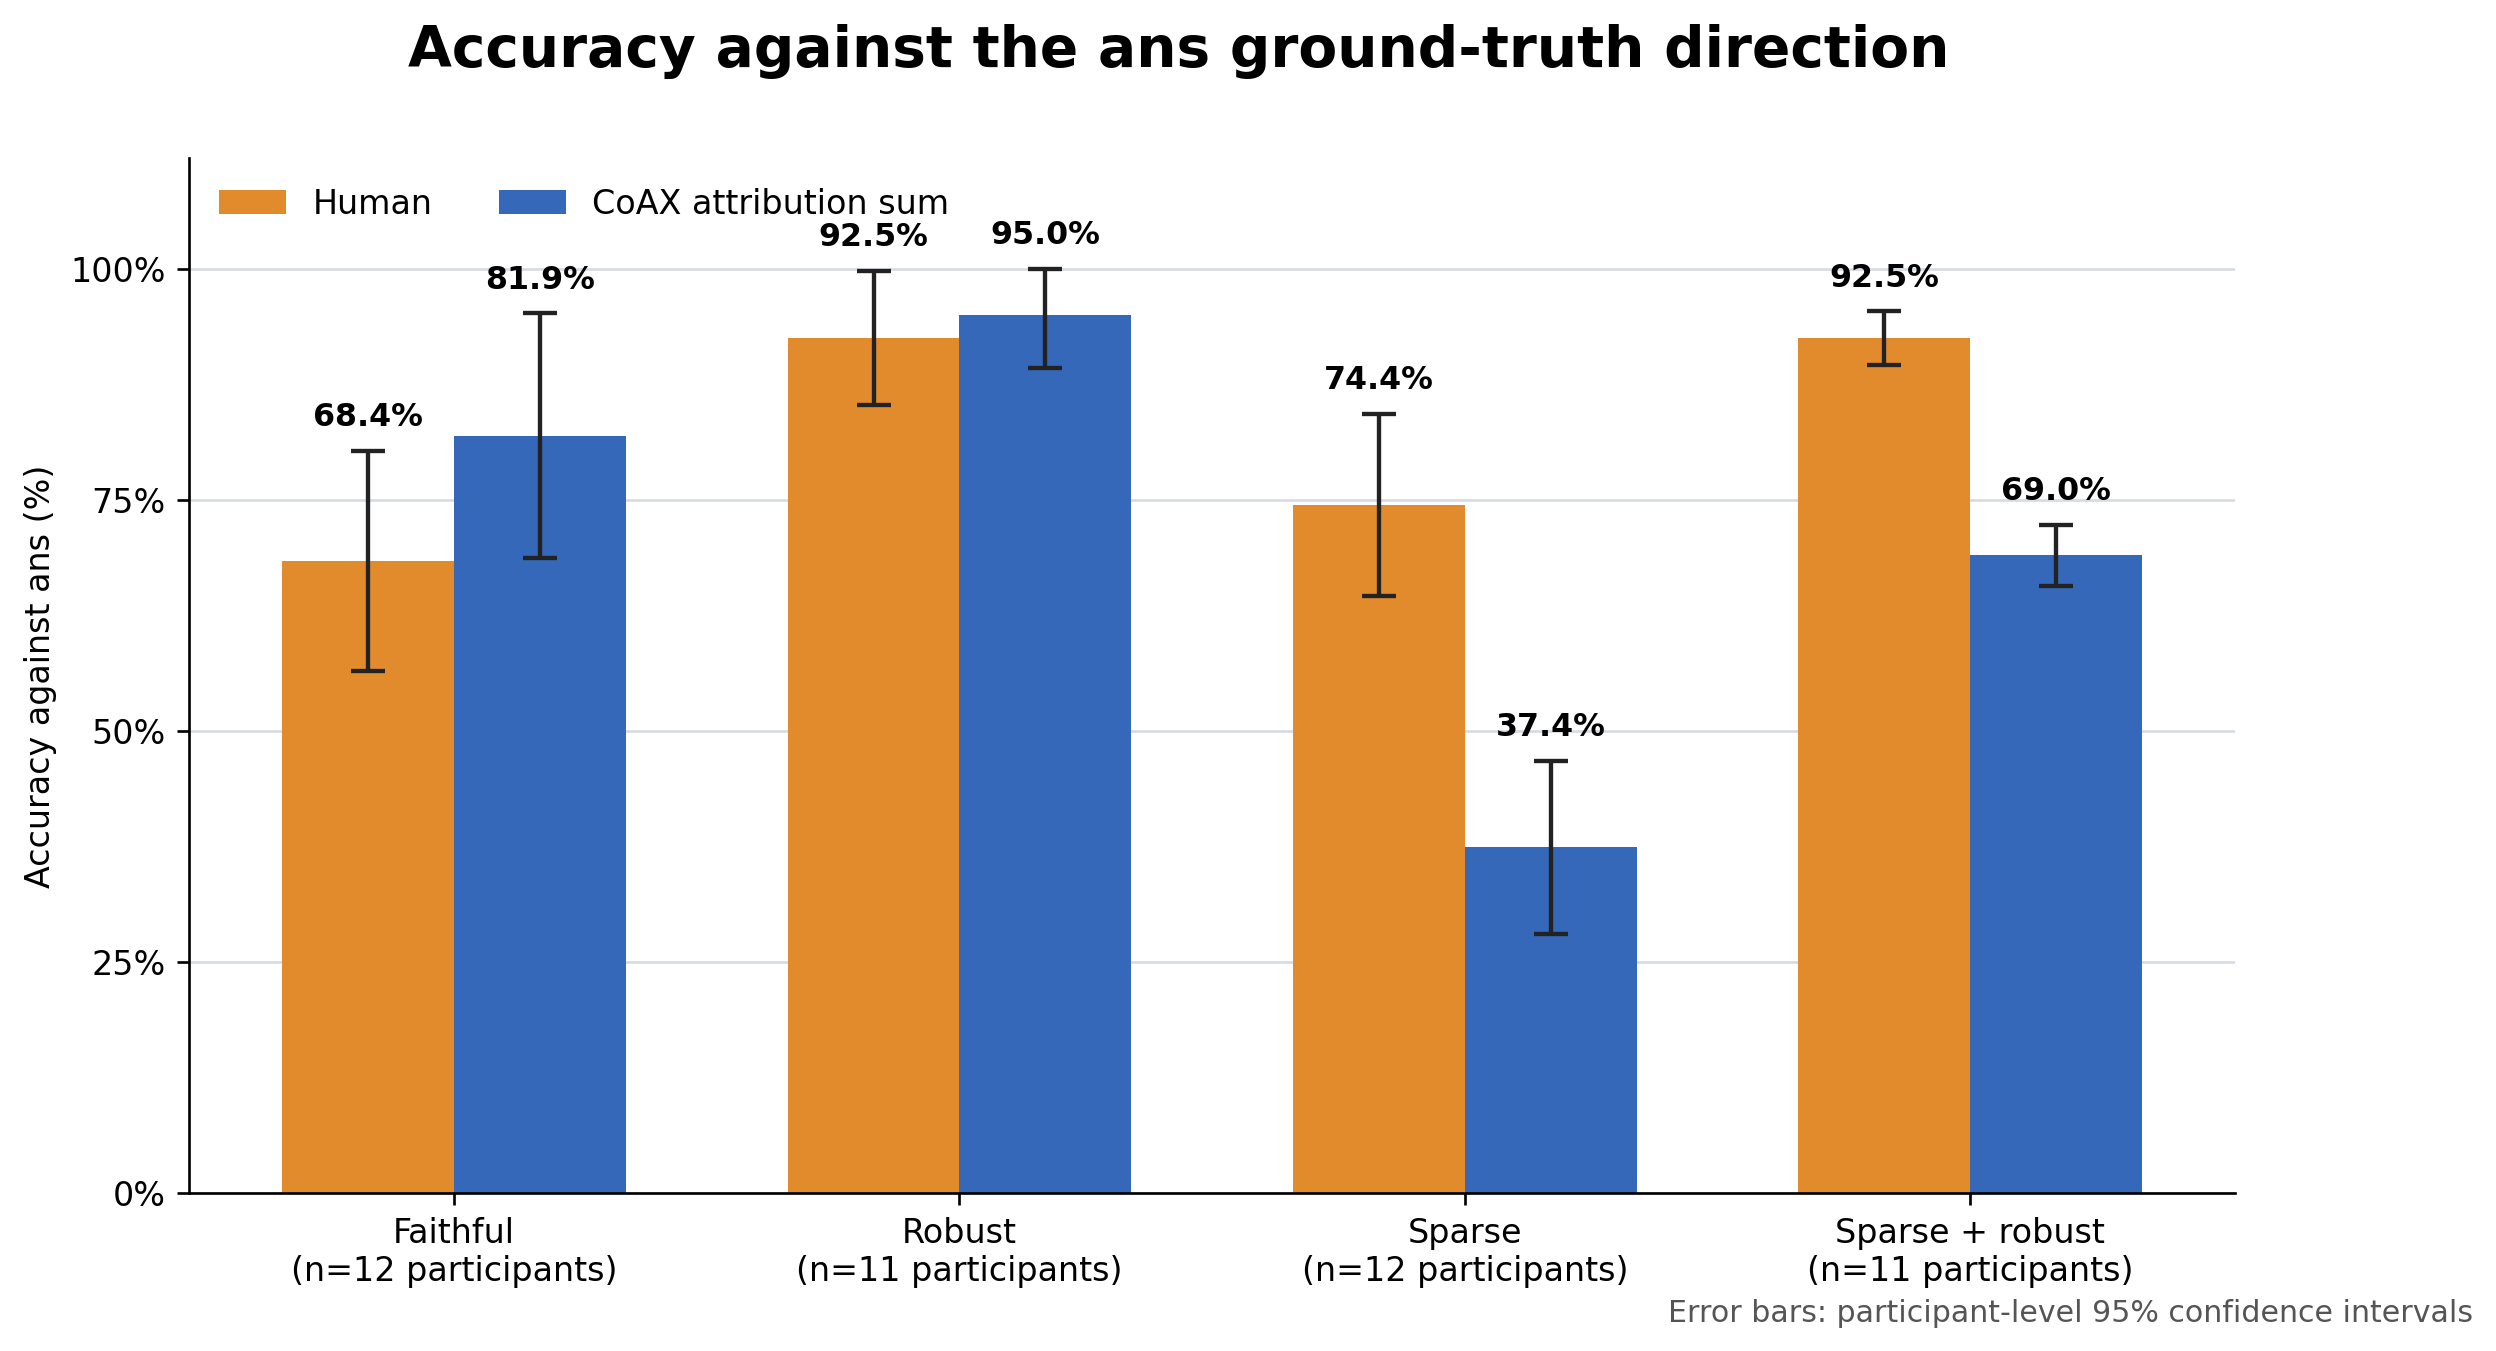

/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/server_runs/sim2real_attribution_sum/human_vs_coax_vertical_bars.png


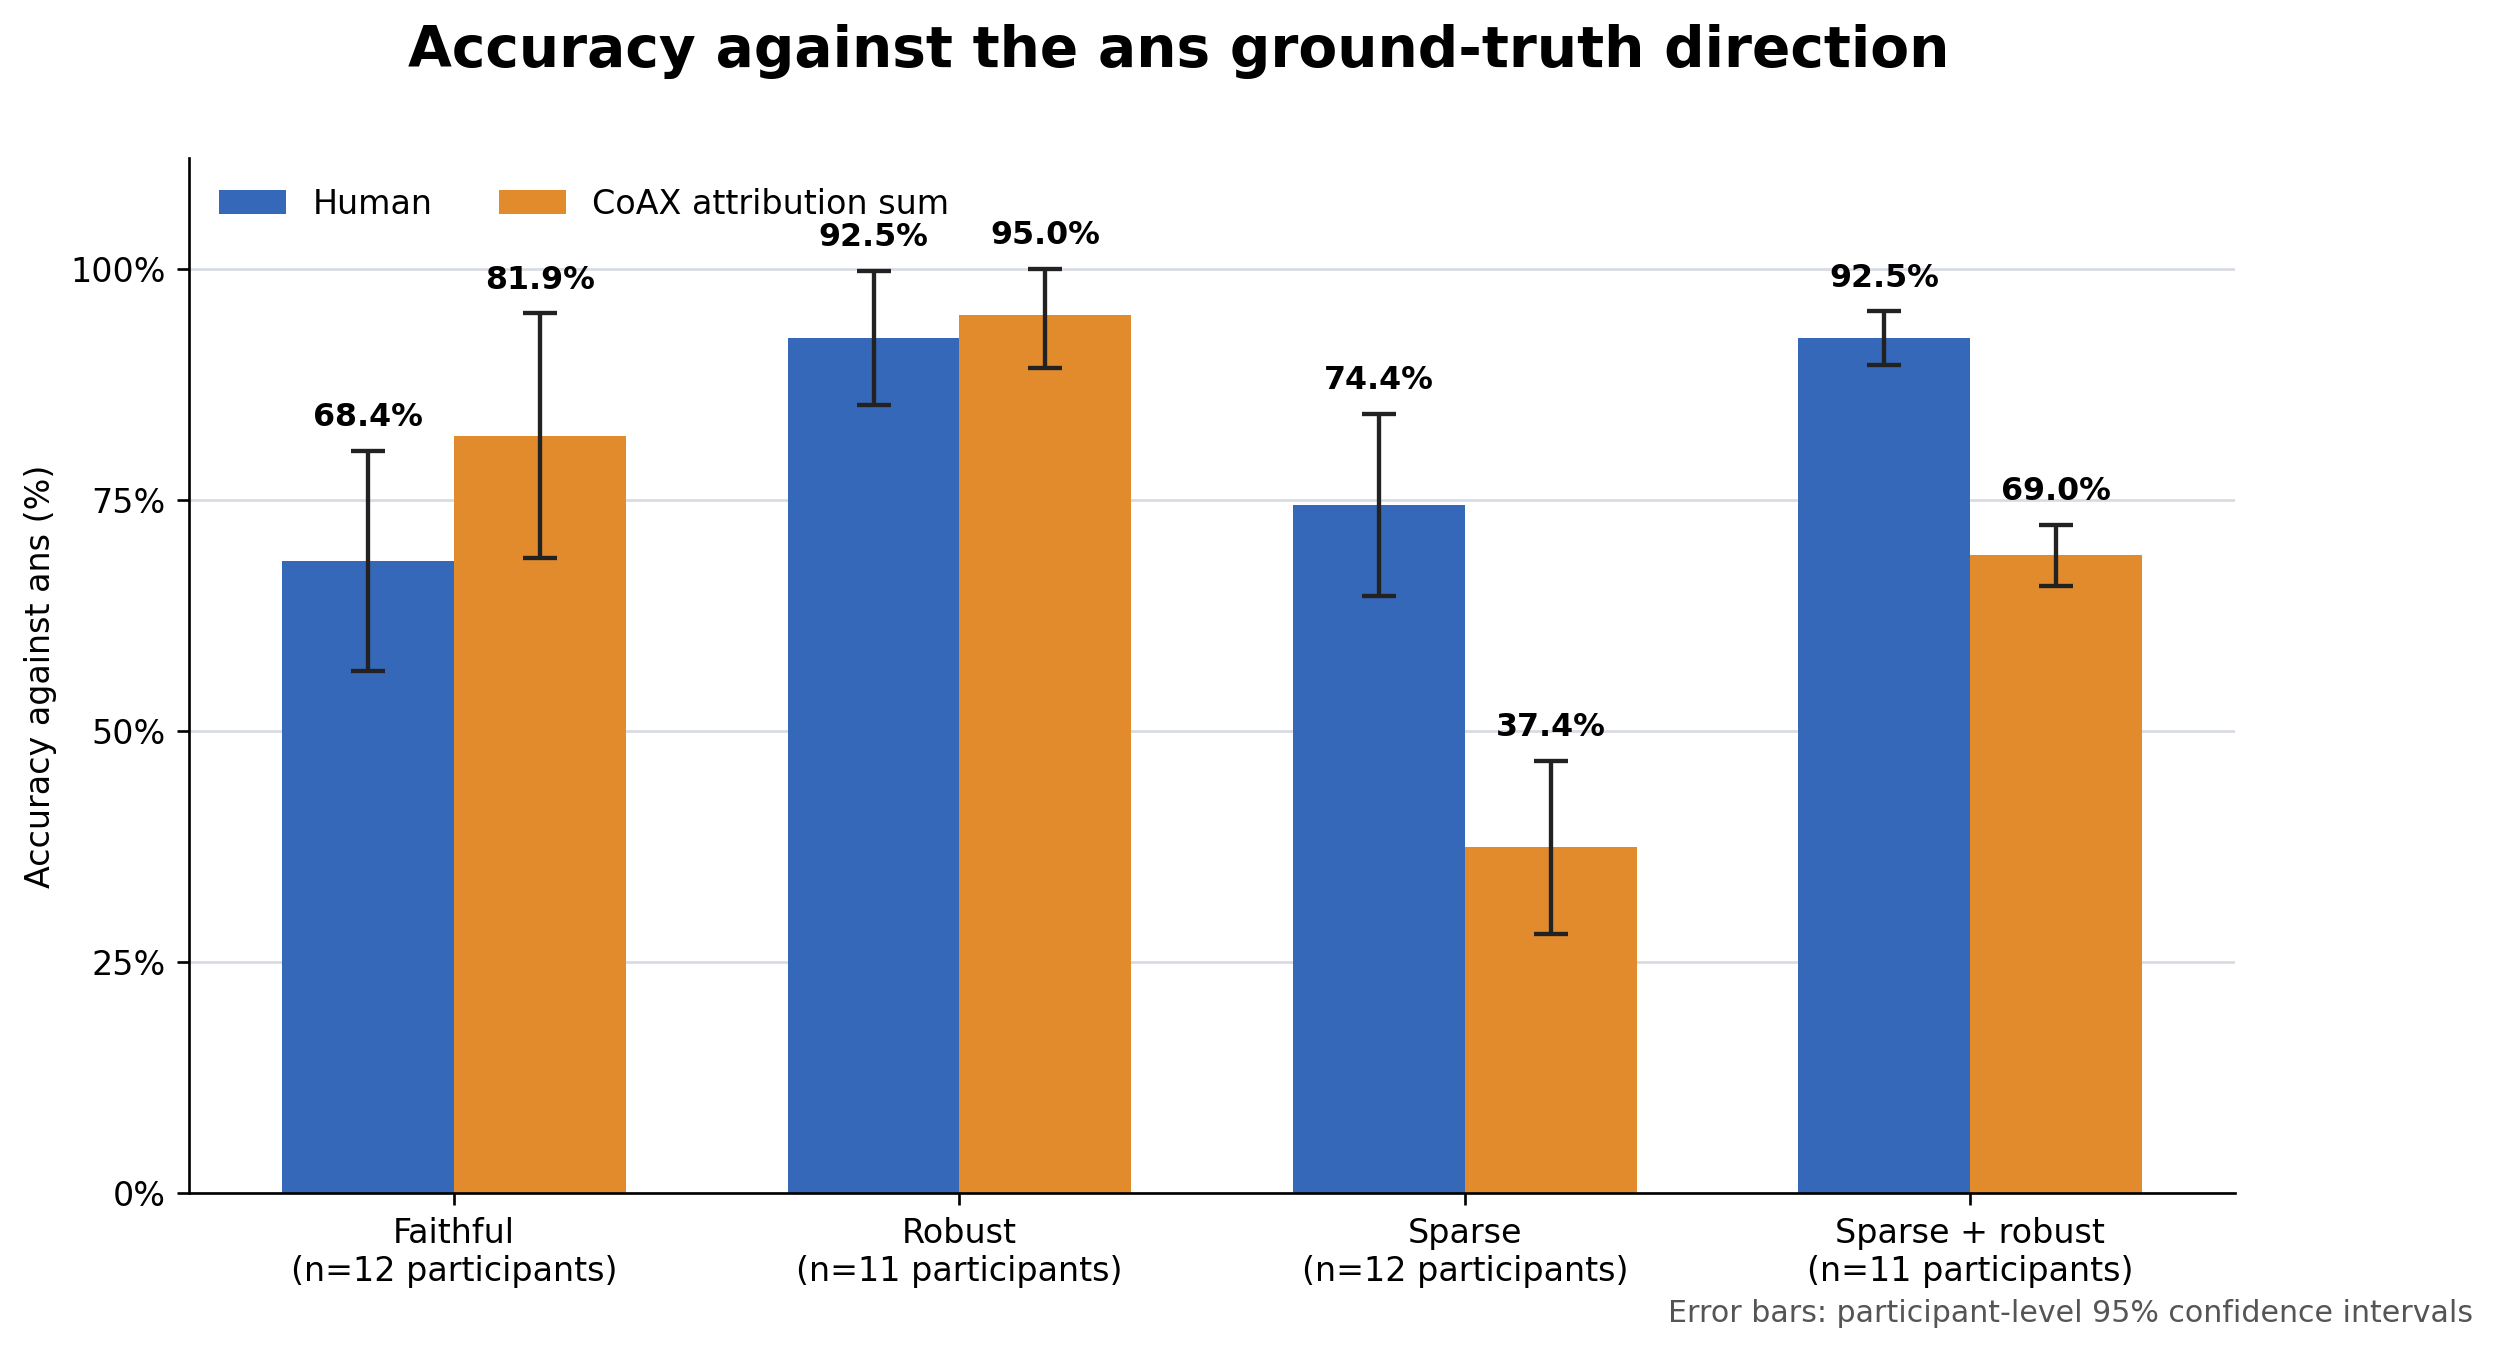

/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/server_runs/sim2real_attribution_sum_lapse/human_vs_coax_ans_accuracy_lapse.png


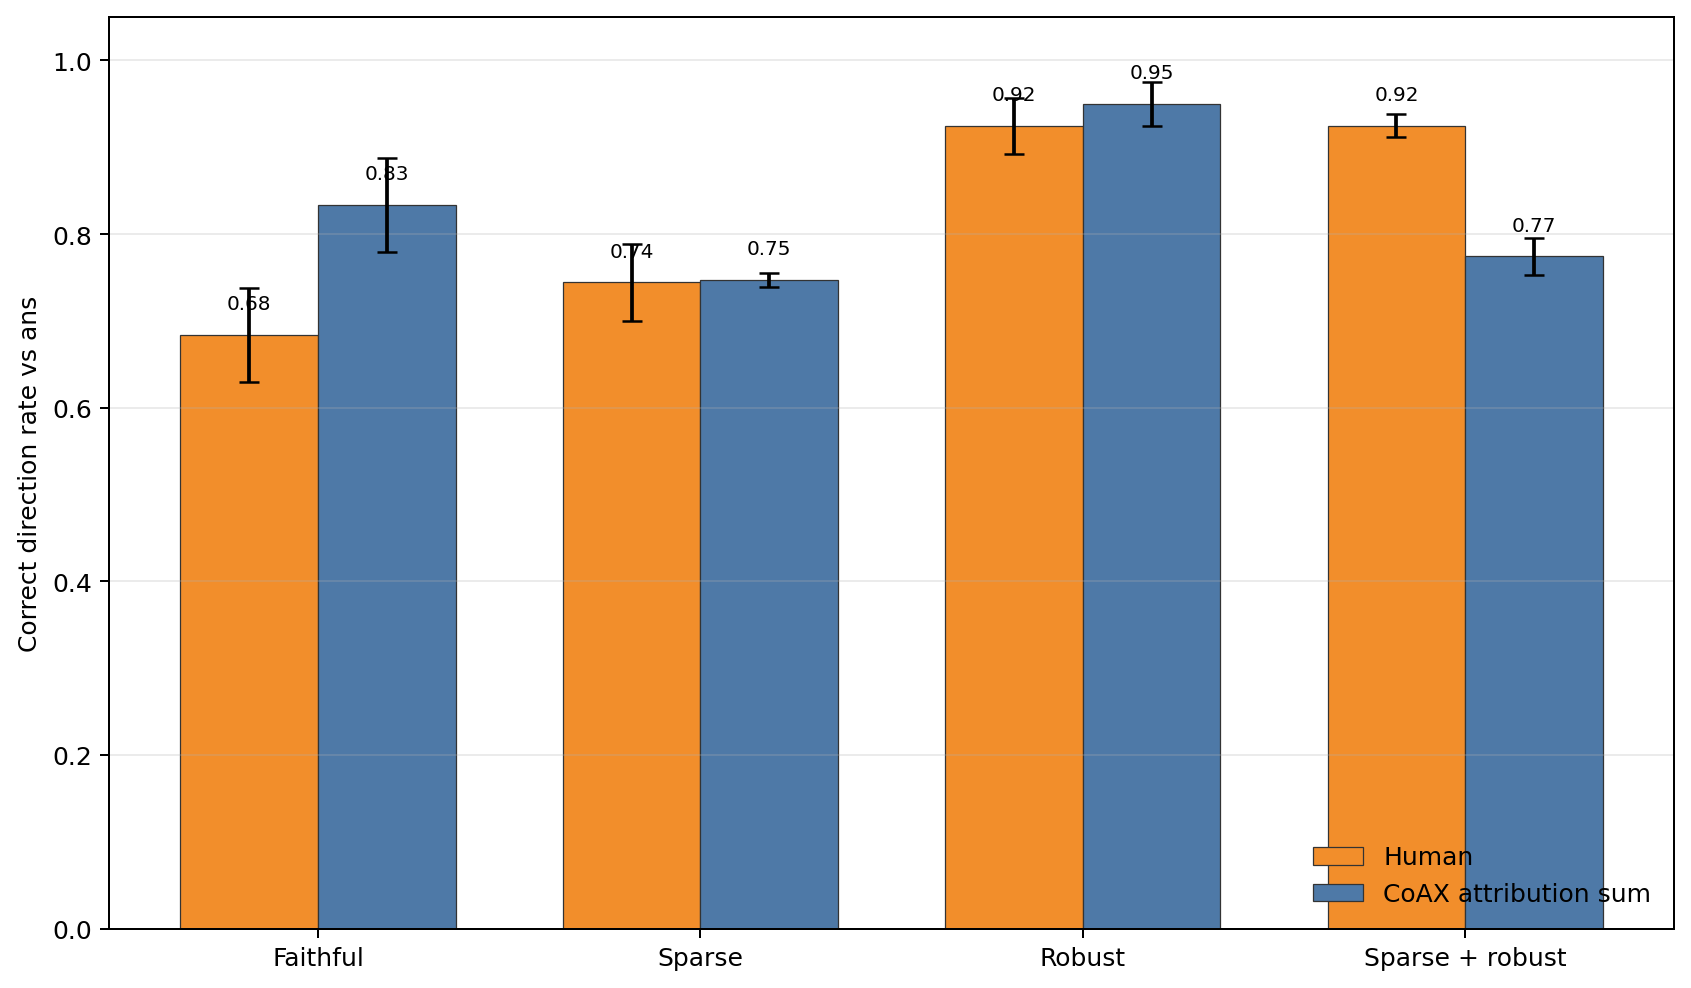

/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/server_runs/sim2real_attribution_sum_lapse_condition_specific/human_vs_coax_ans_accuracy_condition_specific.png


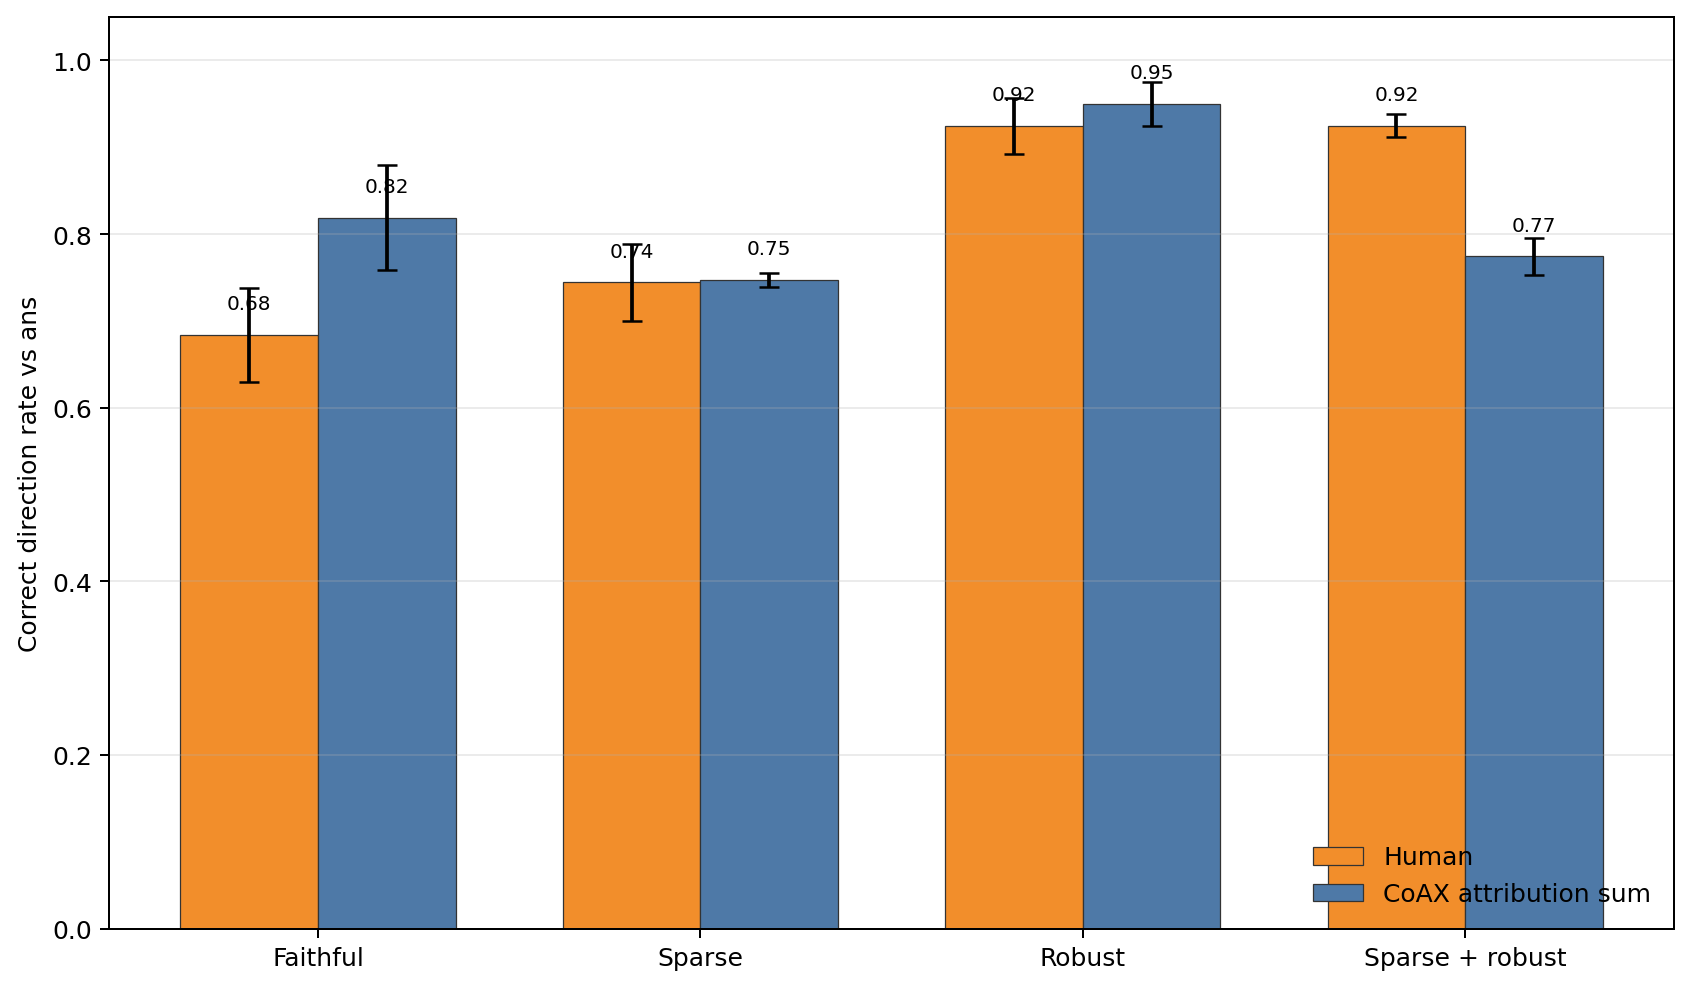

In [15]:
fit_plot_paths = [
    REPO_ROOT / "server_runs" / "sim2real_attribution_sum" / "human_vs_coax_ans_accuracy.png",
    REPO_ROOT / "server_runs" / "sim2real_attribution_sum" / "human_vs_coax_vertical_bars.png",
    REPO_ROOT / "server_runs" / "sim2real_attribution_sum_lapse" / "human_vs_coax_ans_accuracy_lapse.png",
    REPO_ROOT / "server_runs" / "sim2real_attribution_sum_lapse_condition_specific" / "human_vs_coax_ans_accuracy_condition_specific.png",
]

for path in fit_plot_paths:
    if path.is_file():
        print(path)
        display(Image(filename=str(path)))
    else:
        print("missing:", path)

## 11. Server/API mapping for UI integration

The server does the same routing in `server/pipeline.py`: a Sim2Real design reaches `run_sim2real_study(...)`, which loads the fixed assets and skips AI training at simulation time.

For a UI-driven run, send `POST /api/studies/{study_id}/simulate` with a body such as:

```json
{
  "mode": "whole_experiment",
  "sim2real_strategy": "attribution_sum",
  "sim2real_normalize_by_i_max": true,
  "sim2real_params": null
}
```

If you use the server's trial stage, make sure those generated trials are constrained to `sim2real_available_instance_ids()`. The local notebook builds rows directly from those ids for the same reason.